**Import Libraries**

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Libraries imported successfully")

Libraries imported successfully


 **Dataset Statistics**

In [4]:
# Dataset paths
train_path = '../dataset/train'
val_path = '../dataset/val'
test_path = '../dataset/test'

# Function to count images
def count_images(folder_path):
    counts = {}
    for class_name in ['with_mask', 'without_mask']:
        class_path = os.path.join(folder_path, class_name)
        if os.path.exists(class_path):
            counts[class_name] = len(os.listdir(class_path))
        else:
            counts[class_name] = 0
    return counts

train_counts = count_images(train_path)
val_counts = count_images(val_path)
test_counts = count_images(test_path)

print("="*60)
print("DATASET STATISTICS")
print("="*60)
print(f"\nTraining:")
print(f"  With Mask: {train_counts['with_mask']}")
print(f"  Without Mask: {train_counts['without_mask']}")
print(f"\nValidation:")
print(f"  With Mask: {val_counts['with_mask']}")
print(f"  Without Mask: {val_counts['without_mask']}")
print(f"\nTesting:")
print(f"  With Mask: {test_counts['with_mask']}")
print(f"  Without Mask: {test_counts['without_mask']}")

total_train = sum(train_counts.values())
total_val = sum(val_counts.values())
total_test = sum(test_counts.values())
print(f"\nTotal Training: {total_train}")
print(f"Total Validation: {total_val}")
print(f"Total Testing: {total_test}")

DATASET STATISTICS

Training:
  With Mask: 2980
  Without Mask: 3063

Validation:
  With Mask: 372
  Without Mask: 382

Testing:
  With Mask: 373
  Without Mask: 383

Total Training: 6043
Total Validation: 754
Total Testing: 756


**Class Distribution Bar Chart**

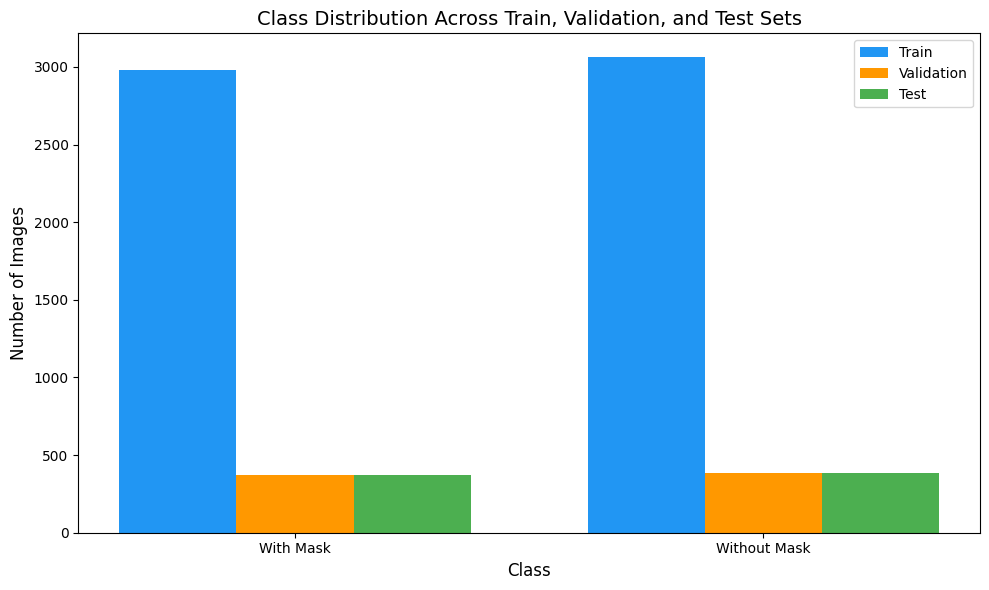

In [5]:
# Bar chart for class distribution across splits
classes = ['With Mask', 'Without Mask']
train_values = [train_counts['with_mask'], train_counts['without_mask']]
val_values = [val_counts['with_mask'], val_counts['without_mask']]
test_values = [test_counts['with_mask'], test_counts['without_mask']]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, train_values, width, label='Train', color='#2196F3')
ax.bar(x, val_values, width, label='Validation', color='#FF9800')
ax.bar(x + width, test_values, width, label='Test', color='#4CAF50')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution Across Train, Validation, and Test Sets', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

plt.tight_layout()
plt.savefig('../results/class_distribution_bar.png', dpi=300, bbox_inches='tight')
plt.show()


**Training Set Pie Chart**

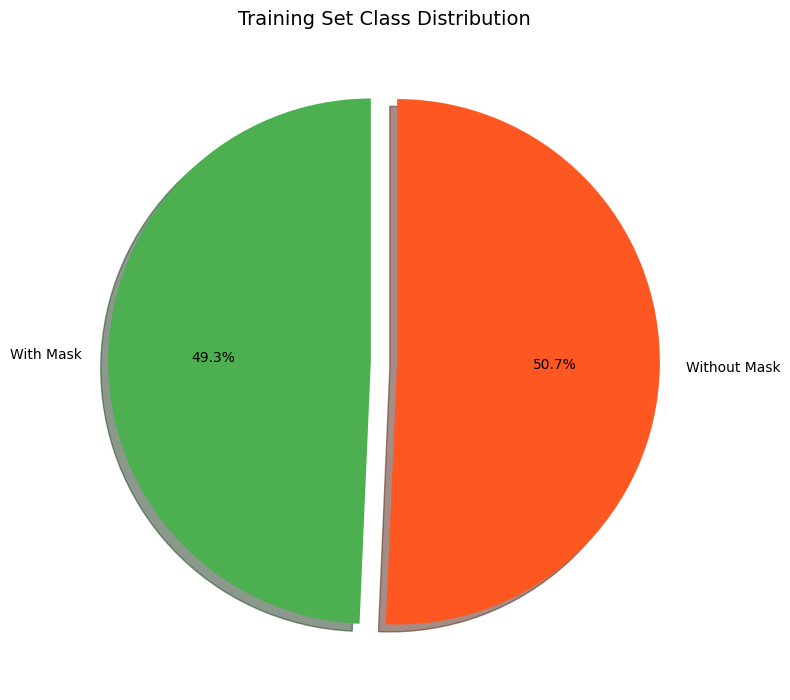

In [6]:
# Pie chart for training set
plt.figure(figsize=(8, 8))
train_values = [train_counts['with_mask'], train_counts['without_mask']]
labels = ['With Mask', 'Without Mask']
colors = ['#4CAF50', '#FF5722']
explode = (0.05, 0.05)

plt.pie(train_values, labels=labels, autopct='%1.1f%%', colors=colors,
        explode=explode, startangle=90, shadow=True)
plt.title('Training Set Class Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('../results/train_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Validation Set Pie Chart**

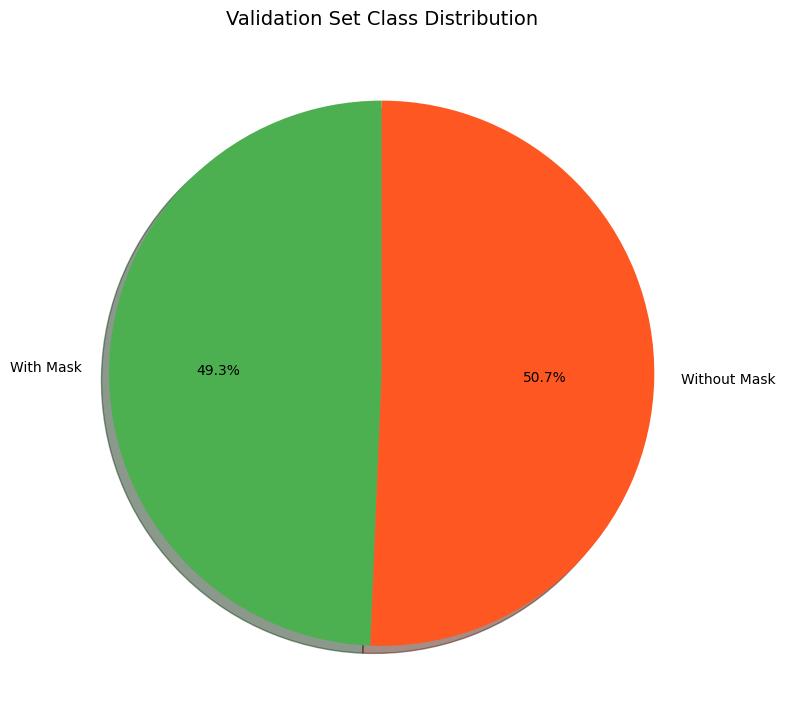

In [7]:
# Pie chart for validation set
plt.figure(figsize=(8, 8))
val_values = [val_counts['with_mask'], val_counts['without_mask']]
labels = ['With Mask', 'Without Mask']
colors = ['#4CAF50', '#FF5722']

plt.pie(val_values, labels=labels, autopct='%1.1f%%', colors=colors,
        startangle=90, shadow=True)
plt.title('Validation Set Class Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('../results/val_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Test Set Pie Chart**

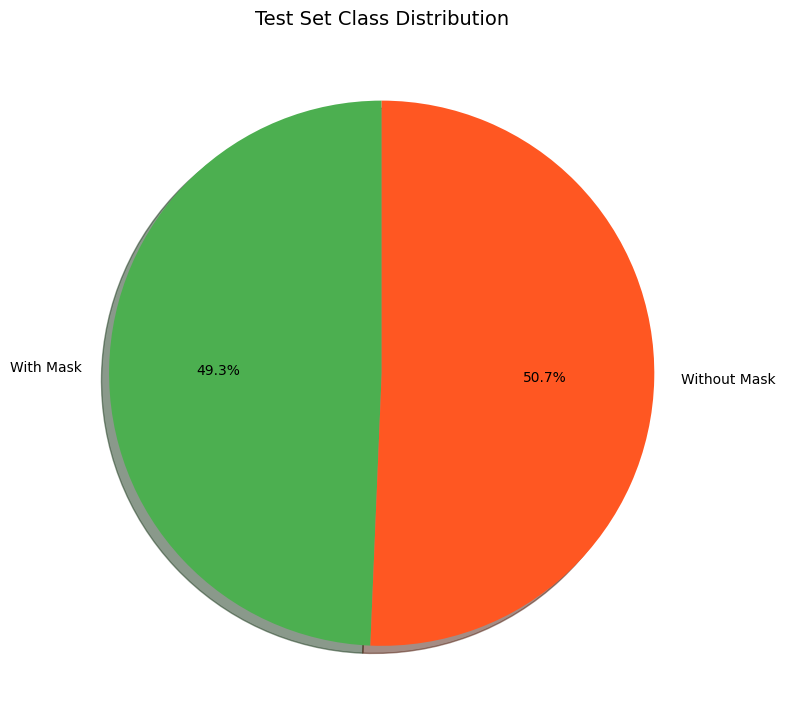

In [8]:
# Pie chart for test set
plt.figure(figsize=(8, 8))
test_values = [test_counts['with_mask'], test_counts['without_mask']]
labels = ['With Mask', 'Without Mask']
colors = ['#4CAF50', '#FF5722']

plt.pie(test_values, labels=labels, autopct='%1.1f%%', colors=colors,
        startangle=90, shadow=True)
plt.title('Test Set Class Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('../results/test_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Sample Images Grid (With Mask)**

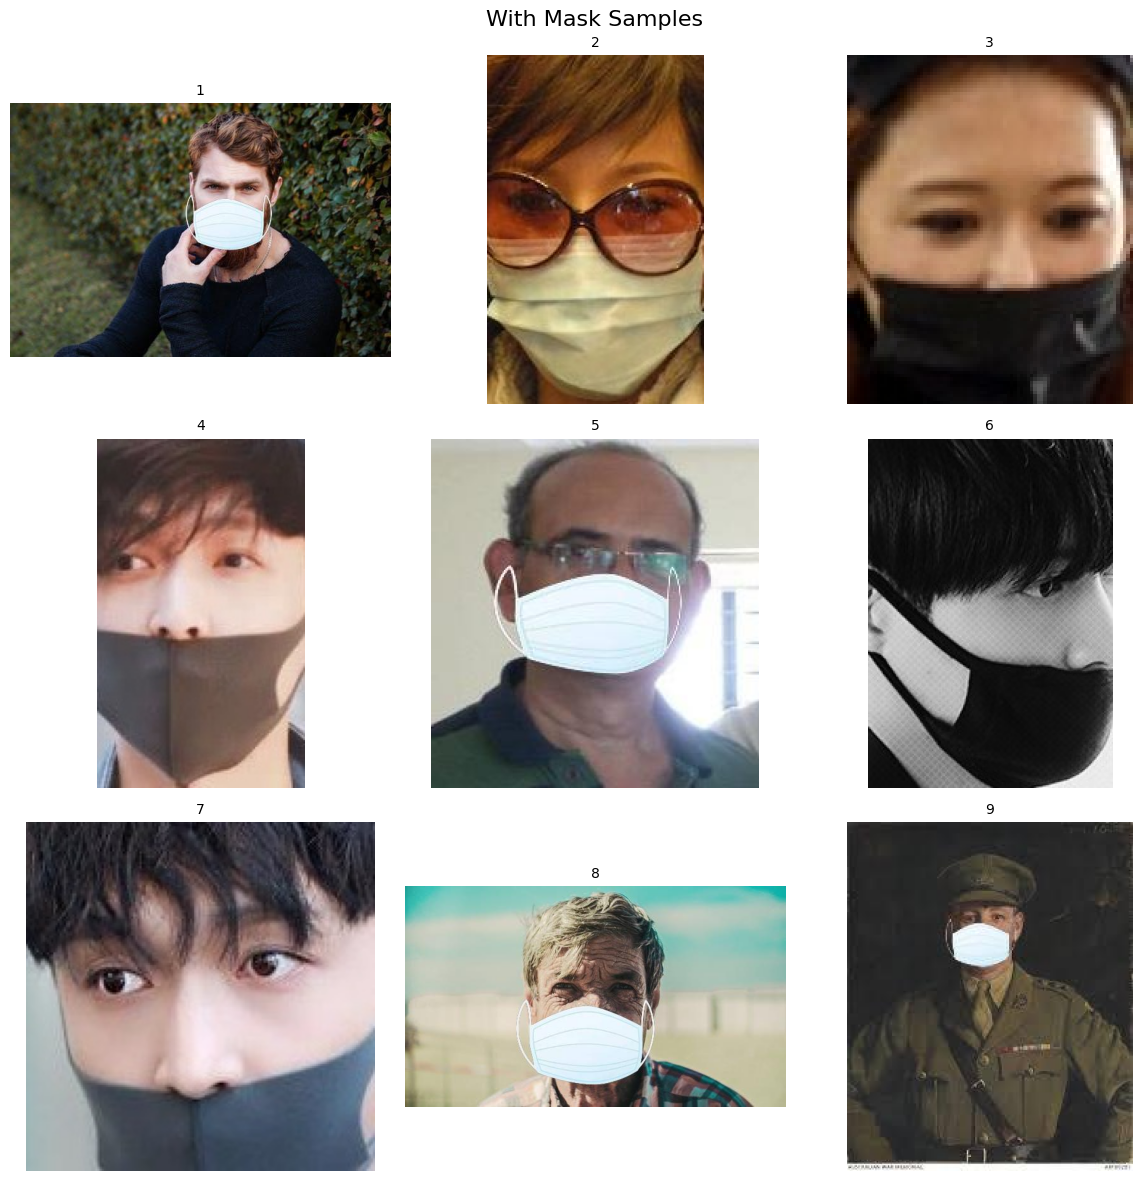

In [9]:
# Display sample images with mask
def plot_sample_grid(class_path, title, num_images=9):
    images = os.listdir(class_path)[:num_images]
    cols = 3
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    axes = axes.flatten()
    
    for i, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f'{i+1}', fontsize=10)
    
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(f'../results/{title.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_sample_grid('../dataset/train/with_mask', 'With Mask Samples')

**Sample Images Grid (Without Mask)**

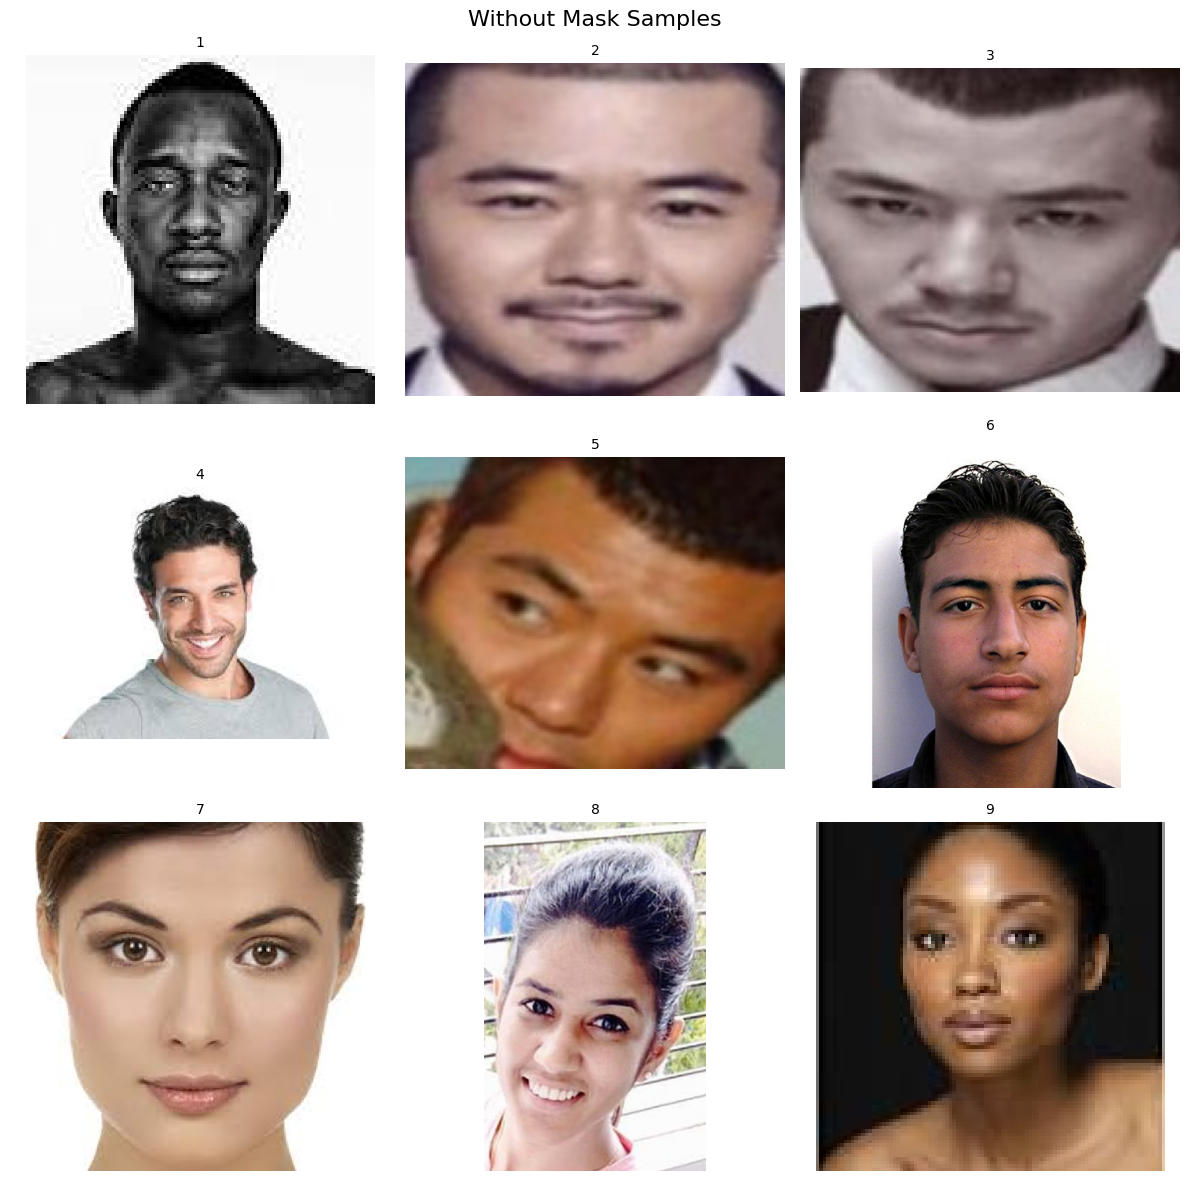

In [10]:
plot_sample_grid('../dataset/train/without_mask', 'Without Mask Samples')

 **Image Width Distribution (With Mask)**

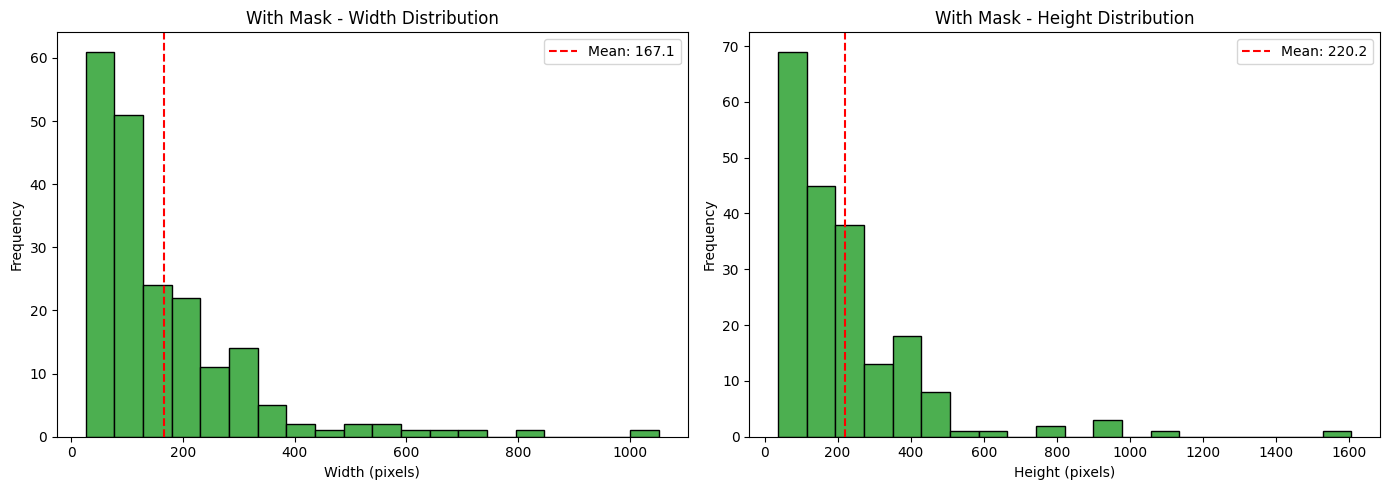

In [11]:
# Analyze and plot image dimensions
def analyze_dimensions(folder_path, num_samples=200):
    widths = []
    heights = []
    
    images = os.listdir(folder_path)[:num_samples]
    for img_name in images:
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]
            heights.append(h)
            widths.append(w)
    
    return widths, heights

# With Mask dimensions
w1, h1 = analyze_dimensions('../dataset/train/with_mask')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(w1, bins=20, color='#4CAF50', edgecolor='black')
axes[0].set_title('With Mask - Width Distribution', fontsize=12)
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(w1), color='red', linestyle='--', label=f'Mean: {np.mean(w1):.1f}')
axes[0].legend()

axes[1].hist(h1, bins=20, color='#4CAF50', edgecolor='black')
axes[1].set_title('With Mask - Height Distribution', fontsize=12)
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(h1), color='red', linestyle='--', label=f'Mean: {np.mean(h1):.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/with_mask_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

**Image Width Distribution (Without Mask)**

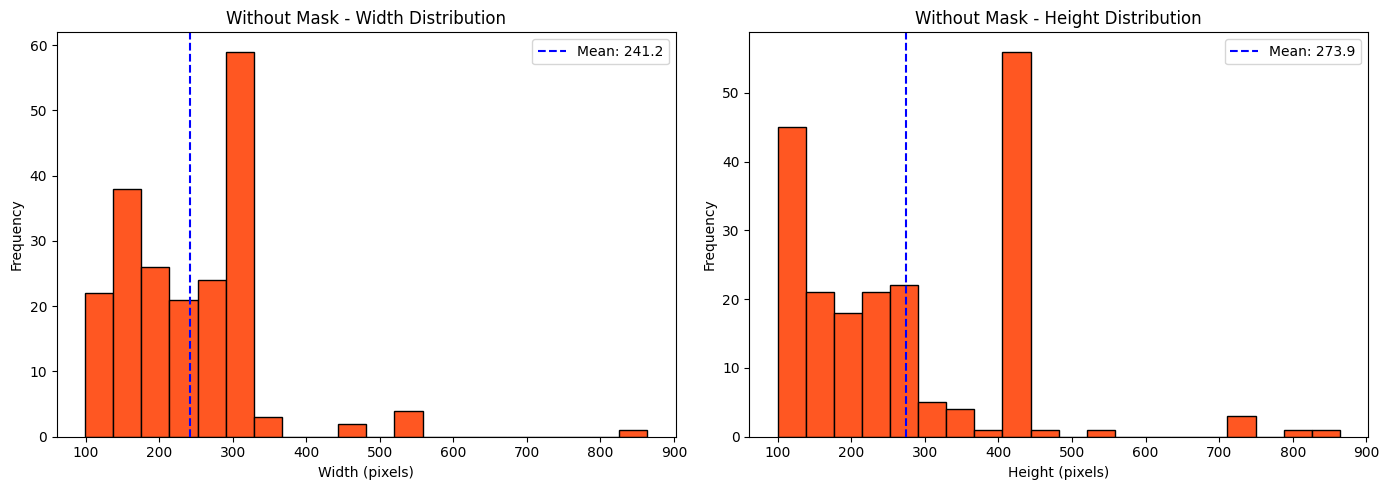

In [12]:
# Without Mask dimensions
w2, h2 = analyze_dimensions('../dataset/train/without_mask')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(w2, bins=20, color='#FF5722', edgecolor='black')
axes[0].set_title('Without Mask - Width Distribution', fontsize=12)
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(w2), color='blue', linestyle='--', label=f'Mean: {np.mean(w2):.1f}')
axes[0].legend()

axes[1].hist(h2, bins=20, color='#FF5722', edgecolor='black')
axes[1].set_title('Without Mask - Height Distribution', fontsize=12)
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(h2), color='blue', linestyle='--', label=f'Mean: {np.mean(h2):.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/without_mask_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

**Dataset Summary Table**

In [14]:
# Create a summary table
summary_data = {
    'Dataset Split': ['Training', 'Validation', 'Testing'],
    'With Mask': [
        train_counts['with_mask'],
        val_counts['with_mask'],
        test_counts['with_mask']
    ],
    'Without Mask': [
        train_counts['without_mask'],
        val_counts['without_mask'],
        test_counts['without_mask']
    ],
    'Total': [
        sum(train_counts.values()),
        sum(val_counts.values()),
        sum(test_counts.values())
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("DATASET SUMMARY TABLE")
print("="*60)
print(summary_df.to_string(index=False))

# Save summary table
summary_df.to_csv('../results/dataset_summary.csv', index=False)
print("\n Summary saved to: results/dataset_summary.csv")


DATASET SUMMARY TABLE
Dataset Split  With Mask  Without Mask  Total
     Training       2980          3063   6043
   Validation        372           382    754
      Testing        373           383    756

 Summary saved to: results/dataset_summary.csv


**Observations**

In [16]:
print("="*60)
print("EDA OBSERVATIONS")
print("="*60)

total_overall = total_train + total_val + total_test

observations = f"""
1. Class Distribution:
   - Both classes are relatively balanced across all splits.
   - No significant class imbalance detected.

2. Image Dimensions:
   - Images have varying sizes (different widths and heights).
   - All images will be resized to 224x224 during preprocessing.

3. Dataset Split:
   - Training: 80% of total images
   - Validation: 10% of total images
   - Testing: 10% of total images

4. Data Quality:
   - No corrupted images found.
   - All images are in RGB format (3 channels).

5. Total Images:
   - Training: {total_train}
   - Validation: {total_val}
   - Testing: {total_test}
   - Overall: {total_overall}
"""

print(observations)

# Save observations
with open('../results/eda_observations.txt', 'w') as f:
    f.write(observations)
print("\n Observations saved to: results/eda_observations.txt")

EDA OBSERVATIONS

1. Class Distribution:
   - Both classes are relatively balanced across all splits.
   - No significant class imbalance detected.

2. Image Dimensions:
   - Images have varying sizes (different widths and heights).
   - All images will be resized to 224x224 during preprocessing.

3. Dataset Split:
   - Training: 80% of total images
   - Validation: 10% of total images
   - Testing: 10% of total images

4. Data Quality:
   - No corrupted images found.
   - All images are in RGB format (3 channels).

5. Total Images:
   - Training: 6043
   - Validation: 754
   - Testing: 756
   - Overall: 7553


 Observations saved to: results/eda_observations.txt
